# Commerce Purchase Prediction — EDA

**Goal:** Understand the dataset deeply and translate findings into modeling strategy.

**Table of Contents**
1. Setup & Data Load
2. Basic Overview
3. User Activity Analysis (Cold Start)
4. Item Popularity Analysis (Long-tail)
5. Event Type Funnel Analysis
6. Temporal Pattern Analysis
7. Category & Brand Analysis
8. Price Analysis
9. Repeat Purchase Analysis
10. Train/Test Continuity Analysis
11. Interaction Matrix Sparsity
12. Strategy Summary

---
## 1. Setup & Data Load

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

DATA_DIR = './data/'  # change to your data path

In [4]:
print('Loading data...')
df = pd.read_parquet(DATA_DIR + 'train.parquet')

df['event_time'] = pd.to_datetime(df['event_time'])
df['date']       = df['event_time'].dt.date
df['year_month'] = df['event_time'].dt.to_period('M')
df['hour']       = df['event_time'].dt.hour
df['dayofweek']  = df['event_time'].dt.dayofweek  # 0 = Monday
df['week']       = df['event_time'].dt.isocalendar().week.astype(int)

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
df.head(3)

Loading data...
Loaded: 8,350,311 rows x 13 cols


,user_id,item_id,user_session,event_time,category_code,brand,price,event_type,date,year_month,hour,dayofweek,week
0,0b517454-e7c3-44ec-8c39-a68ef9c0ec60,18c11cbb-a18d-4a9e-bdea-6abd3f7d3c04,ad97f19a-f5fb-41ea-a7b2-52c21fb37ab2,2019-11-16 16:31:26+00:00,apparel.shoes,kapika,72.05,view,2019-11-16,2019-11,16,5,46
1,215eeee5-f9c5-4213-8641-7561dbdad1b9,47c5a6da-32d0-4a29-8b51-57304f476ded,6058b45b-bdb9-4d6c-b300-42dcb1cb8280,2019-11-04 18:59:50+00:00,apparel.shoes,respect,82.63,view,2019-11-04,2019-11,18,0,45
2,a25bf14a-49ac-49bb-87de-ee6b300f0cc4,a6d915c6-2bb7-4393-a556-c327723d3666,28a8b8e3-b374-435d-9d5d-b96058ecb75b,2019-11-26 09:01:47+00:00,apparel.tshirt,goodloot,24.43,view,2019-11-26,2019-11,9,1,48


---
## 2. Basic Overview

In [5]:
print('=' * 55)
print('Basic Statistics')
print('=' * 55)
print(f"Total events       : {len(df):>12,}")
print(f"Unique users       : {df['user_id'].nunique():>12,}")
print(f"Unique items       : {df['item_id'].nunique():>12,}")
print(f"Unique sessions    : {df['user_session'].nunique():>12,}")
print(f"Category codes     : {df['category_code'].nunique():>12,}")
print(f"Brands             : {df['brand'].nunique():>12,}")
print(f"Period             : {df['event_time'].min().date()} to {df['event_time'].max().date()}")
print()
print('Missing values:')
print(df.isnull().sum().to_string())

Basic Statistics
Total events       :    8,350,311
Unique users       :      638,257
Unique items       :       29,502
Unique sessions    :    2,889,552
Category codes     :           24
Brands             :        1,859
Period             : 2019-11-01 to 2020-02-29

Missing values:
user_id          0
item_id          0
user_session     0
event_time       0
category_code    0
brand            0
price            0
event_type       0
date             0
year_month       0
hour             0
dayofweek        0
week             0


In [6]:
df['category_code'].unique()

array(['apparel.shoes', 'apparel.tshirt', 'apparel.skirt',
       'apparel.shoes.keds', 'apparel.shoes.moccasins', 'apparel.dress',
       'apparel.costume', 'apparel.jumper', 'apparel.glove',
       'apparel.trousers', 'apparel.underwear', 'apparel.shirt',
       'apparel.shoes.sandals', 'apparel.jeans',
       'apparel.shoes.ballet_shoes', 'apparel.scarf',
       'apparel.shoes.espadrilles', 'apparel.shoes.slipons',
       'apparel.shoes.step_ins', 'apparel.belt', 'apparel.sock',
       'apparel.shorts', 'apparel.pajamas', 'apparel.jacket'],
      dtype=object)


Event Type Distribution
  view      : 8,331,873  (99.8%)
  cart      :    16,362  (0.2%)
  purchase  :     2,076  (0.0%)


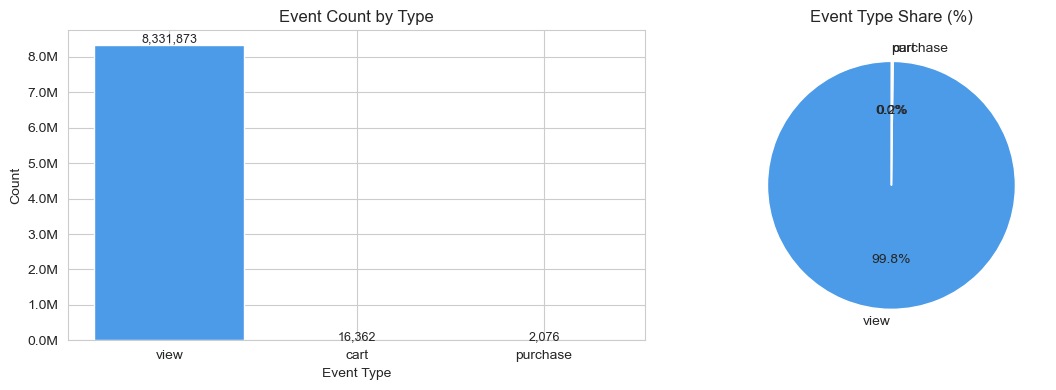


Strategy Insight:
  - view:cart:purchase ratio = 4013:8:1
  - ALS label weight starting point -> view=1, cart=24, purchase=20
  - The sparser the purchase signal, the more each purchase event matters



In [7]:
event_counts = df['event_type'].value_counts()
event_pct    = df['event_type'].value_counts(normalize=True) * 100

print('\nEvent Type Distribution')
for et in event_counts.index:
    print(f"  {et:<10}: {event_counts[et]:>9,}  ({event_pct[et]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'view': '#4C9BE8', 'cart': '#F5A623', 'purchase': '#1D9E75'}
axes[0].bar(event_counts.index, event_counts.values,
            color=[colors.get(e, '#999') for e in event_counts.index])
axes[0].set_title('Event Count by Type')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, (et, v) in enumerate(event_counts.items()):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(event_counts.values, labels=event_counts.index, autopct='%1.1f%%',
            colors=[colors.get(e, '#999') for e in event_counts.index],
            startangle=90)
axes[1].set_title('Event Type Share (%)')

plt.tight_layout()
plt.show()

purchase_cnt = event_counts.get('purchase', 0)
view_cnt     = event_counts.get('view', 0)
cart_cnt     = event_counts.get('cart', 0)
print(f"""
Strategy Insight:
  - view:cart:purchase ratio = {view_cnt/purchase_cnt:.0f}:{cart_cnt/purchase_cnt:.0f}:1
  - ALS label weight starting point -> view=1, cart={cart_cnt/purchase_cnt*3:.0f}, purchase=20
  - The sparser the purchase signal, the more each purchase event matters
""")


Event Type Distribution
  view      : 8,331,873  (99.8%)
  cart      :    16,362  (0.2%)
  purchase  :     2,076  (0.0%)


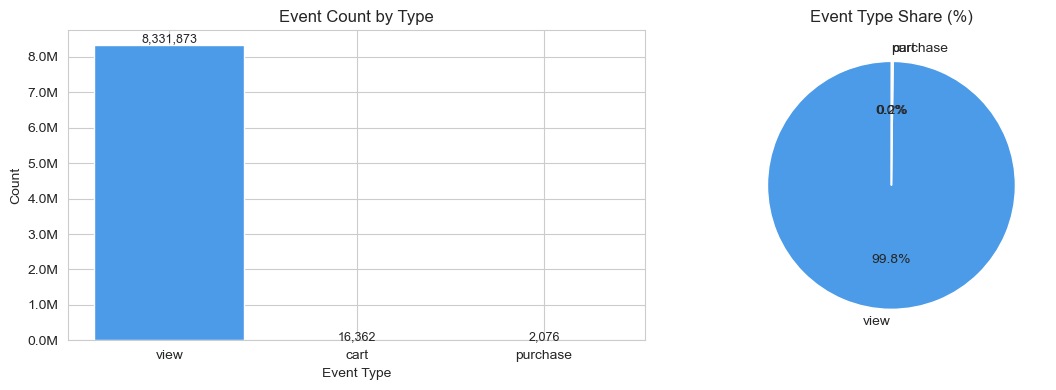

In [8]:
print('\nEvent Type Distribution')
for et in event_counts.index:
    print(f"  {et:<10}: {event_counts[et]:>9,}  ({event_pct[et]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'view': '#4C9BE8', 'cart': '#F5A623', 'purchase': '#1D9E75'}
axes[0].bar(event_counts.index, event_counts.values,
            color=[colors.get(e, '#999') for e in event_counts.index])
axes[0].set_title('Event Count by Type')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, (et, v) in enumerate(event_counts.items()):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(event_counts.values, labels=event_counts.index, autopct='%1.1f%%',
            colors=[colors.get(e, '#999') for e in event_counts.index],
            startangle=90)
axes[1].set_title('Event Type Share (%)')

plt.tight_layout()
plt.show()


---
## 3. User Activity Analysis — Cold Start

In [9]:
user_event_cnt    = df.groupby('user_id').size()
user_purchase_cnt = df[df['event_type']=='purchase'].groupby('user_id').size()

print('Events per User')
print(user_event_cnt.describe().apply(lambda x: f'{x:.1f}').to_string())
print()
print('Purchases per User')
print(user_purchase_cnt.describe().apply(lambda x: f'{x:.1f}').to_string())

Events per User
count    638257.0
mean         13.1
std          58.8
min           1.0
25%           2.0
50%           6.0
75%          15.0
max       37207.0

Purchases per User
count    1681.0
mean        1.2
std         0.8
min         1.0
25%         1.0
50%         1.0
75%         1.0
max        11.0


In [10]:
total_users = df['user_id'].nunique()

print('Cold Start Users (by event count threshold)')
print(f"{'Threshold':<12} {'Users':>12} {'Ratio':>8}")
print('-' * 35)
for t in [1, 2, 3, 5, 10, 20]:
    cold = (user_event_cnt <= t).sum()
    print(f"<= {t:<9} {cold:>12,} {cold/total_users*100:>7.1f}%")

print()
users_with_purchase = user_purchase_cnt.index
users_no_purchase   = total_users - len(users_with_purchase)
print(f"No purchase history : {users_no_purchase:,} ({users_no_purchase/total_users*100:.1f}%)")
print(f"Has purchase history: {len(users_with_purchase):,} ({len(users_with_purchase)/total_users*100:.1f}%)")

Cold Start Users (by event count threshold)
Threshold           Users    Ratio
-----------------------------------
<= 1              107,422    16.8%
<= 2              175,305    27.5%
<= 3              226,101    35.4%
<= 5              302,903    47.5%
<= 10             419,065    65.7%
<= 20             528,732    82.8%

No purchase history : 636,576 (99.7%)
Has purchase history: 1,681 (0.3%)


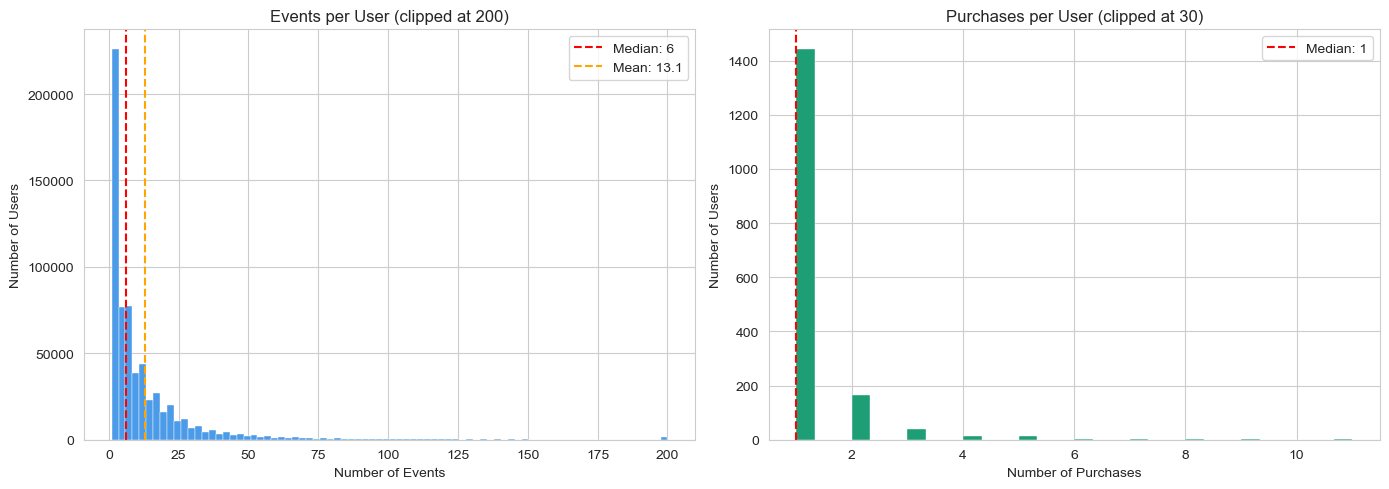

Strategy Insight:
  - Low median -> most users have very few interactions -> hard to personalize
  - Lower SASRec user_inter_num_interval from [5,Inf) to [3,Inf) to include more users
  - Users with no purchases -> fallback to popular items
  - Improvement: use viewed sub-category to serve category-level popular items


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_event_cnt.clip(upper=200), bins=80,
             color='#4C9BE8', edgecolor='white', linewidth=0.3)
axes[0].set_title('Events per User (clipped at 200)')
axes[0].set_xlabel('Number of Events')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(user_event_cnt.median(), color='red', linestyle='--',
                label=f'Median: {user_event_cnt.median():.0f}')
axes[0].axvline(user_event_cnt.mean(), color='orange', linestyle='--',
                label=f'Mean: {user_event_cnt.mean():.1f}')
axes[0].legend()

axes[1].hist(user_purchase_cnt.clip(upper=30), bins=30,
             color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].set_title('Purchases per User (clipped at 30)')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Users')
axes[1].axvline(user_purchase_cnt.median(), color='red', linestyle='--',
                label=f'Median: {user_purchase_cnt.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Strategy Insight:')
print('  - Low median -> most users have very few interactions -> hard to personalize')
print('  - Lower SASRec user_inter_num_interval from [5,Inf) to [3,Inf) to include more users')
print('  - Users with no purchases -> fallback to popular items')
print('  - Improvement: use viewed sub-category to serve category-level popular items')

In [12]:
print('Included Users by SASRec inter_num Threshold')
for t in [3, 5, 10]:
    included = (user_event_cnt >= t).sum()
    excluded = total_users - included
    print(f"  Threshold {t}: included {included:,} ({included/total_users*100:.1f}%) / "
          f"cold-start fallback {excluded:,} ({excluded/total_users*100:.1f}%)")

Included Users by SASRec inter_num Threshold
  Threshold 3: included 462,952 (72.5%) / cold-start fallback 175,305 (27.5%)
  Threshold 5: included 369,978 (58.0%) / cold-start fallback 268,279 (42.0%)
  Threshold 10: included 238,403 (37.4%) / cold-start fallback 399,854 (62.6%)


---
## 4. Item Popularity — Long-tail Distribution

In [13]:
item_event_cnt    = df.groupby('item_id').size().sort_values(ascending=False)
item_purchase_cnt = (df[df['event_type']=='purchase']
                     .groupby('item_id').size().sort_values(ascending=False))
total_items = df['item_id'].nunique()

print('Events per Item')
print(item_event_cnt.describe().apply(lambda x: f'{x:.1f}').to_string())
print()
print('Purchases per Item')
print(item_purchase_cnt.describe().apply(lambda x: f'{x:.1f}').to_string())

Events per Item
count     29502.0
mean        283.0
std        1262.4
min           1.0
25%          30.0
50%          77.0
75%         221.0
max      143759.0

Purchases per Item
count    996.0
mean       2.1
std        6.8
min        1.0
25%        1.0
50%        1.0
75%        2.0
max      188.0


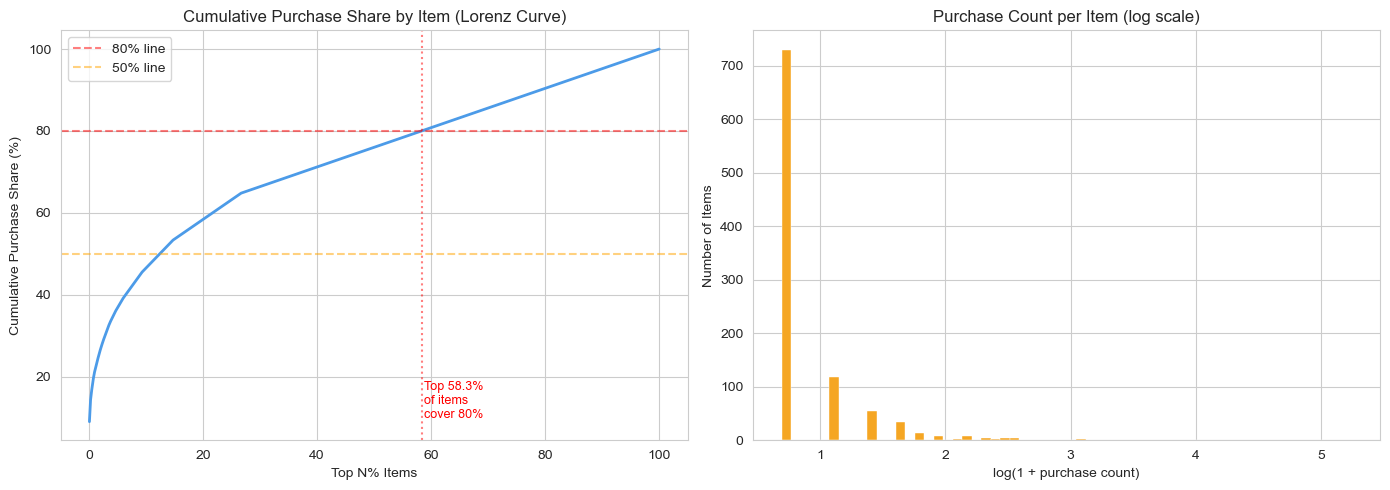

  Top    10 items account for 21.2% of all purchases
  Top   100 items account for 46.6% of all purchases
  Top  1000 items account for 100.0% of all purchases

Strategy Insight:
  - Heavy long-tail -> popular items are effective for cold-start users
  - If top-10 items cover >20% of purchases, popular baseline is very strong


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

purchase_by_item = item_purchase_cnt.values
cum_pct_items    = np.arange(1, len(purchase_by_item)+1) / len(purchase_by_item) * 100
cum_pct_events   = np.cumsum(purchase_by_item) / purchase_by_item.sum() * 100

axes[0].plot(cum_pct_items, cum_pct_events, color='#4C9BE8', linewidth=2)
axes[0].axhline(80, color='red',    linestyle='--', alpha=0.5, label='80% line')
axes[0].axhline(50, color='orange', linestyle='--', alpha=0.5, label='50% line')
axes[0].set_title('Cumulative Purchase Share by Item (Lorenz Curve)')
axes[0].set_xlabel('Top N% Items')
axes[0].set_ylabel('Cumulative Purchase Share (%)')
axes[0].legend()

idx_80 = np.searchsorted(cum_pct_events, 80)
if idx_80 < len(cum_pct_items):
    axes[0].axvline(cum_pct_items[idx_80], color='red', linestyle=':', alpha=0.5)
    axes[0].text(cum_pct_items[idx_80]+0.5, 10,
                 f'Top {cum_pct_items[idx_80]:.1f}%\nof items\ncover 80%',
                 fontsize=9, color='red')

axes[1].hist(np.log1p(item_purchase_cnt.values), bins=60,
             color='#F5A623', edgecolor='white', linewidth=0.3)
axes[1].set_title('Purchase Count per Item (log scale)')
axes[1].set_xlabel('log(1 + purchase count)')
axes[1].set_ylabel('Number of Items')

plt.tight_layout()
plt.show()

for top_n in [10, 100, 1000]:
    pct = item_purchase_cnt.head(top_n).sum() / item_purchase_cnt.sum() * 100
    print(f"  Top {top_n:>5} items account for {pct:.1f}% of all purchases")

print('\nStrategy Insight:')
print('  - Heavy long-tail -> popular items are effective for cold-start users')
print('  - If top-10 items cover >20% of purchases, popular baseline is very strong')

In [15]:
print('Top 20 Items by Purchase Count')
top20_items = item_purchase_cnt.head(20).reset_index()
top20_items.columns = ['item_id', 'purchase_count']
item_meta   = df[['item_id','category_code','brand','price']].drop_duplicates('item_id')
top20_items = top20_items.merge(item_meta, on='item_id', how='left')
print(top20_items.to_string(index=False))

Top 20 Items by Purchase Count
                             item_id  purchase_count         category_code    brand  price
2e0d2baf-84f8-4609-8411-40106770595a             188         apparel.shoes   xiaomi  30.68
fb744b46-11e3-4239-bb72-8ece03a1826a              61         apparel.shoes     sony 391.00
d5eec7ed-8259-4f6b-99b0-53250d8a0bd6              50      apparel.trousers     iqos  43.76
e6503c75-8483-45c3-a1b7-a2631b1e7f3b              26 apparel.shoes.slipons  samsung 100.13
c2d911d7-9cb5-4d05-9116-a52a4a4977f1              23         apparel.shoes   xiaomi  25.43
1dc96fe9-67b0-4088-90f4-61f5c505091d              21 apparel.shoes.slipons    apple 385.80
49a9ea33-3cbd-4087-8168-fbee578948d8              21 apparel.shoes.slipons  samsung 179.90
b4d3d2b6-fd6c-4a3b-b7ed-cb9f199a4734              19         apparel.shoes     sony 341.84
b7a35b0c-cc5e-4ff8-9217-61e2c69918c3              16      apparel.trousers     iqos  95.24
6e13dbe9-8b77-4040-9a11-e71271ab43ff              15      a

---
## 5. Event Type Funnel Analysis

In [16]:
funnel     = df['event_type'].value_counts()
view_n     = funnel.get('view', 0)
cart_n     = funnel.get('cart', 0)
purchase_n = funnel.get('purchase', 0)

print('Purchase Funnel Conversion Rates')
print(f"  view  -> cart    : {cart_n/view_n*100:.2f}%")
print(f"  cart  -> purchase: {purchase_n/cart_n*100:.2f}%")
print(f"  view  -> purchase: {purchase_n/view_n*100:.2f}%")

item_event_type = df.groupby(['item_id','event_type']).size().unstack(fill_value=0)
if 'view' in item_event_type.columns and 'purchase' in item_event_type.columns:
    item_event_type['view_to_purchase_rate'] = (
        item_event_type['purchase'] / item_event_type['view'].replace(0, np.nan)
    )
    print('\nItem-level view->purchase Conversion Rate')
    print(item_event_type['view_to_purchase_rate'].describe().apply(lambda x: f'{x:.4f}').to_string())

Purchase Funnel Conversion Rates
  view  -> cart    : 0.20%
  cart  -> purchase: 12.69%
  view  -> purchase: 0.02%

Item-level view->purchase Conversion Rate
count    29502.0000
mean         0.0002
std          0.0027
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          0.2174


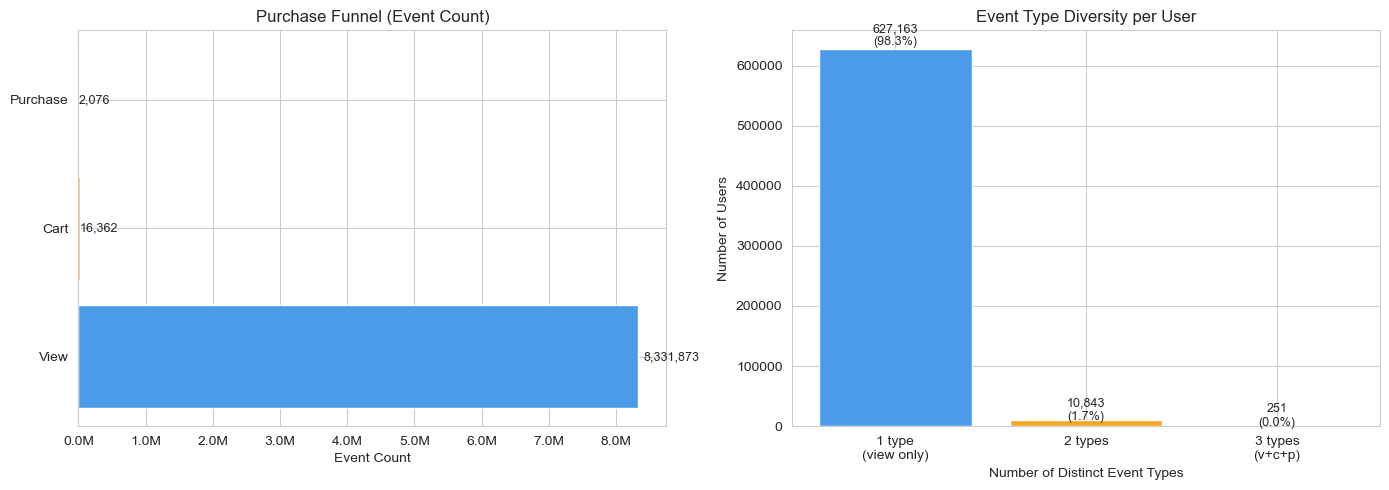

Strategy Insight:
  - High view-only ratio -> ALS label=1 for all events introduces noise
  - Strong justification for heavily weighting cart and purchase over view
  - purchase-only ALS experiment is worth trying


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

funnel_colors = ['#4C9BE8', '#F5A623', '#1D9E75']
bars = axes[0].barh(['View', 'Cart', 'Purchase'],
                    [view_n, cart_n, purchase_n], color=funnel_colors)
axes[0].set_title('Purchase Funnel (Event Count)')
axes[0].set_xlabel('Event Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, val in zip(bars, [view_n, cart_n, purchase_n]):
    axes[0].text(val * 1.01, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

user_event_types = df.groupby('user_id')['event_type'].nunique()
type_dist  = user_event_types.value_counts().sort_index()
labels_map = {1: '1 type\n(view only)', 2: '2 types', 3: '3 types\n(v+c+p)'}
axes[1].bar([labels_map.get(k, str(k)) for k in type_dist.index],
            type_dist.values,
            color=['#4C9BE8','#F5A623','#1D9E75'][:len(type_dist)])
axes[1].set_title('Event Type Diversity per User')
axes[1].set_xlabel('Number of Distinct Event Types')
axes[1].set_ylabel('Number of Users')
for i, v in enumerate(type_dist.values):
    axes[1].text(i, v * 1.01, f'{v:,}\n({v/total_users*100:.1f}%)',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Strategy Insight:')
print('  - High view-only ratio -> ALS label=1 for all events introduces noise')
print('  - Strong justification for heavily weighting cart and purchase over view')
print('  - purchase-only ALS experiment is worth trying')

---
## 6. Temporal Pattern Analysis

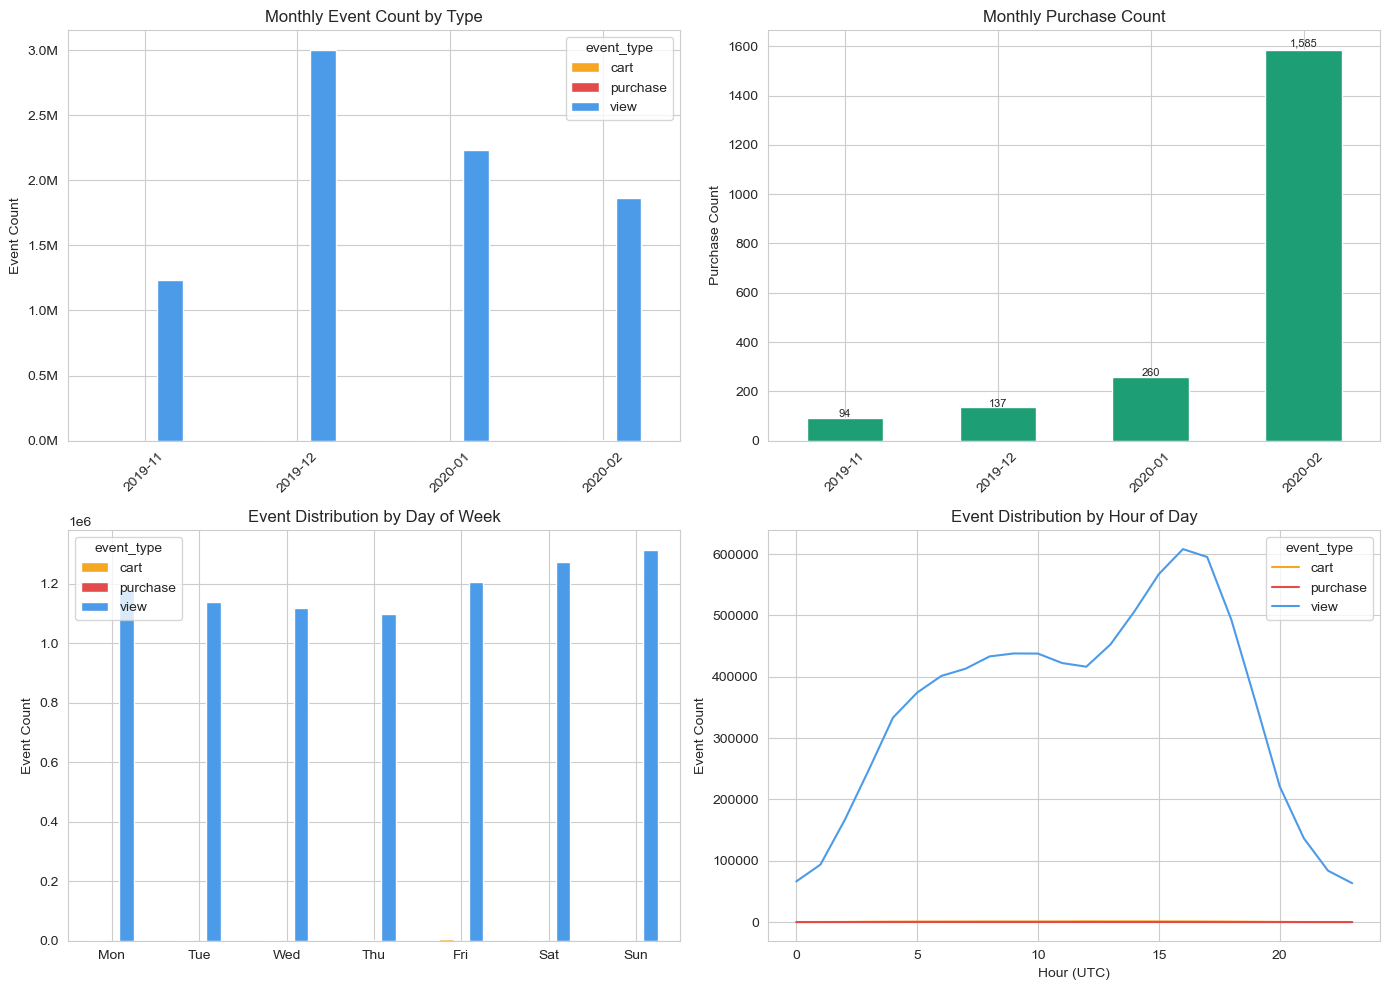

Strategy Insight:
  - Monthly purchase trend -> check for holiday/seasonal effects
  - Recent months deserve higher weight -> supports time decay


In [18]:
monthly = df.groupby(['year_month','event_type']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

monthly.plot(kind='bar', ax=axes[0,0], color=['#F5A623','#E24B4A','#4C9BE8'])
axes[0,0].set_title('Monthly Event Count by Type')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Event Count')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

if 'purchase' in monthly.columns:
    monthly['purchase'].plot(kind='bar', ax=axes[0,1], color='#1D9E75')
    axes[0,1].set_title('Monthly Purchase Count')
    axes[0,1].set_xlabel('')
    axes[0,1].set_ylabel('Purchase Count')
    axes[0,1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(monthly['purchase']):
        axes[0,1].text(i, v*1.01, f'{v:,}', ha='center', fontsize=8)

dow_event = df.groupby(['dayofweek','event_type']).size().unstack(fill_value=0)
dow_event.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][:len(dow_event)]
dow_event.plot(kind='bar', ax=axes[1,0], color=['#F5A623','#E24B4A','#4C9BE8'])
axes[1,0].set_title('Event Distribution by Day of Week')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Event Count')
axes[1,0].tick_params(axis='x', rotation=0)

hour_event = df.groupby(['hour','event_type']).size().unstack(fill_value=0)
hour_event.plot(ax=axes[1,1], color=['#F5A623','#E24B4A','#4C9BE8'])
axes[1,1].set_title('Event Distribution by Hour of Day')
axes[1,1].set_xlabel('Hour (UTC)')
axes[1,1].set_ylabel('Event Count')

plt.tight_layout()
plt.show()

print('Strategy Insight:')
print('  - Monthly purchase trend -> check for holiday/seasonal effects')
print('  - Recent months deserve higher weight -> supports time decay')

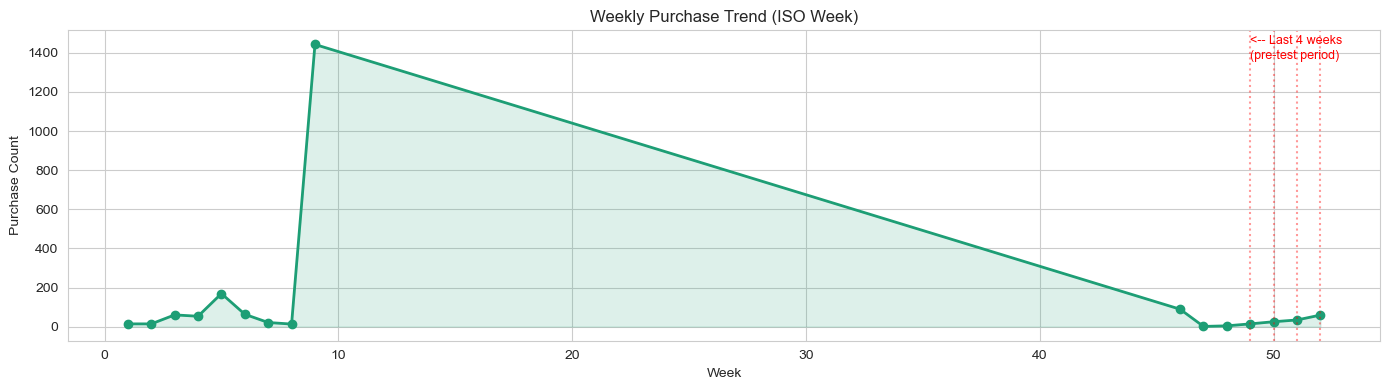

Strategy Insight:
  - The last 4 weeks trend is most relevant for predicting March purchases.
  - Use this to determine the time-decay lambda value.


In [19]:
weekly_purchase = df[df['event_type']=='purchase'].groupby('week').size()

plt.figure(figsize=(14, 4))
plt.plot(weekly_purchase.index, weekly_purchase.values,
         marker='o', color='#1D9E75', linewidth=2)
plt.fill_between(weekly_purchase.index, weekly_purchase.values,
                 alpha=0.15, color='#1D9E75')
plt.title('Weekly Purchase Trend (ISO Week)')
plt.xlabel('Week')
plt.ylabel('Purchase Count')

last_4w = weekly_purchase.index[-4:]
for w in last_4w:
    plt.axvline(w, color='red', linestyle=':', alpha=0.4)
plt.text(last_4w[0], weekly_purchase.max()*0.95,
         '<-- Last 4 weeks\n(pre-test period)', color='red', fontsize=9)

plt.tight_layout()
plt.show()

print('Strategy Insight:')
print('  - The last 4 weeks trend is most relevant for predicting March purchases.')
print('  - Use this to determine the time-decay lambda value.')

---
## 7. Category & Brand Analysis

In [20]:
df['category_top'] = df['category_code'].str.split('.').str[0]
df['category_sub'] = df['category_code'].str.split('.').str[1]

print('Top-level Category Statistics')
cat_stats = df.groupby('category_top').agg(
    total_events = ('event_type', 'count'),
    purchases    = ('event_type', lambda x: (x=='purchase').sum()),
    unique_items = ('item_id', 'nunique'),
    unique_users = ('user_id', 'nunique'),
).sort_values('purchases', ascending=False)
cat_stats['purchase_rate'] = (cat_stats['purchases'] / cat_stats['total_events'] * 100).round(2)
print(cat_stats.head(15).to_string())

Top-level Category Statistics
              total_events  purchases  unique_items  unique_users  purchase_rate
category_top                                                                    
apparel            8350311       2076         29502        638257           0.02


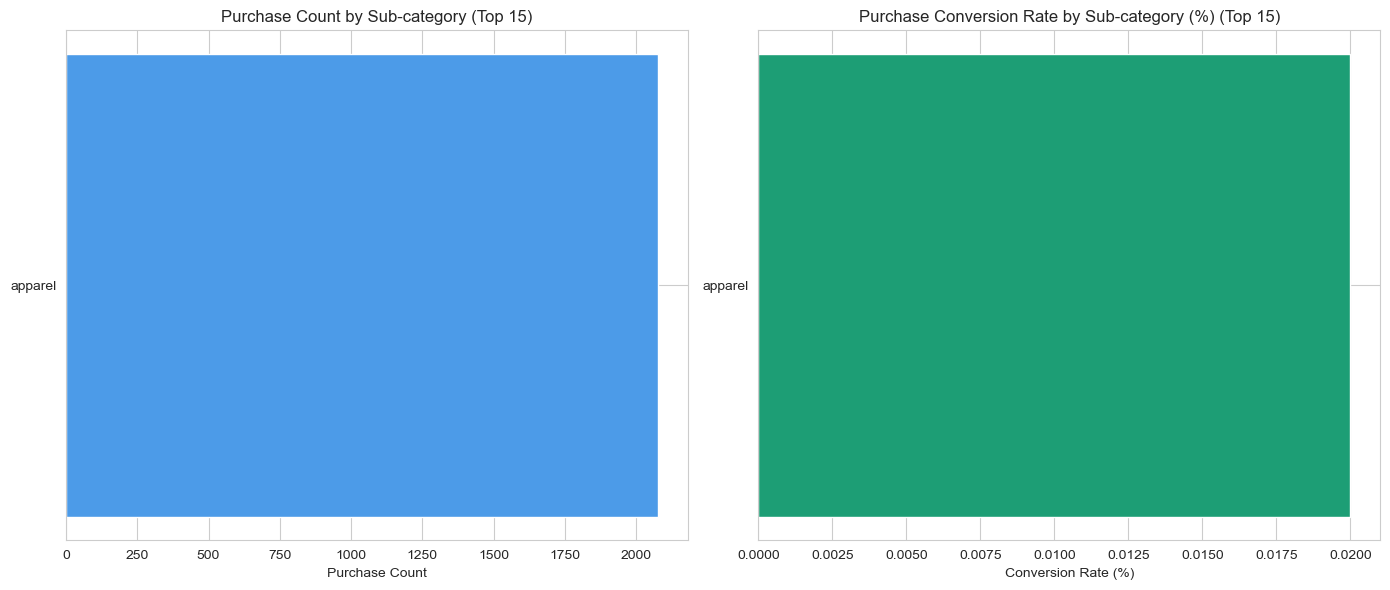

Strategy Insight:
  - High-conversion sub-category -> view events are strong purchase signals
  - Low-conversion sub-category  -> focus only on cart/purchase signals
  - Use sub-category for improved cold-start fallback recommendation


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_cats = cat_stats.head(15)
axes[0].barh(top_cats.index[::-1], top_cats['purchases'][::-1], color='#4C9BE8')
axes[0].set_title('Purchase Count by Sub-category (Top 15)')
axes[0].set_xlabel('Purchase Count')

axes[1].barh(top_cats.index[::-1], top_cats['purchase_rate'][::-1], color='#1D9E75')
axes[1].set_title('Purchase Conversion Rate by Sub-category (%) (Top 15)')
axes[1].set_xlabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

print('Strategy Insight:')
print('  - High-conversion sub-category -> view events are strong purchase signals')
print('  - Low-conversion sub-category  -> focus only on cart/purchase signals')
print('  - Use sub-category for improved cold-start fallback recommendation')

In [22]:
brand_purchase       = df[df['event_type']=='purchase']['brand'].value_counts()
brand_purchase_clean = brand_purchase.dropna()

print(f"Brands: {df['brand'].nunique():,} unique  (missing: {df['brand'].isnull().sum():,})")
print('\nTop 20 Brands by Purchase Count:')
print(brand_purchase_clean.head(20).to_string())

print()
for n in [10, 50, 100]:
    pct = brand_purchase_clean.head(n).sum() / brand_purchase_clean.sum() * 100
    print(f"  Top {n:>4} brands -> {pct:.1f}% of all purchases")

print('\nNote: Brand names appear anonymized (e.g., "samsung shoes"). Use with caution.')

Brands: 1,859 unique  (missing: 0)

Top 20 Brands by Purchase Count:
brand
xiaomi       224
sony         180
samsung      112
iqos         101
respect       74
apple         51
defacto       50
luminarc      43
glo           43
lg            40
nika          32
omron         28
starline      28
bq            27
montale       26
lanvin        22
intex         22
prestigio     21
kingston      20
lenovo        19

  Top   10 brands -> 44.2% of all purchases
  Top   50 brands -> 71.0% of all purchases
  Top  100 brands -> 83.3% of all purchases

Note: Brand names appear anonymized (e.g., "samsung shoes"). Use with caution.


---
## 8. Price Analysis

Price Distribution by Event Type
  view      : mean=151  median=79  min=1  max=2574
  cart      : mean=149  median=66  min=1  max=2558
  purchase  : mean=122  median=64  min=1  max=1593


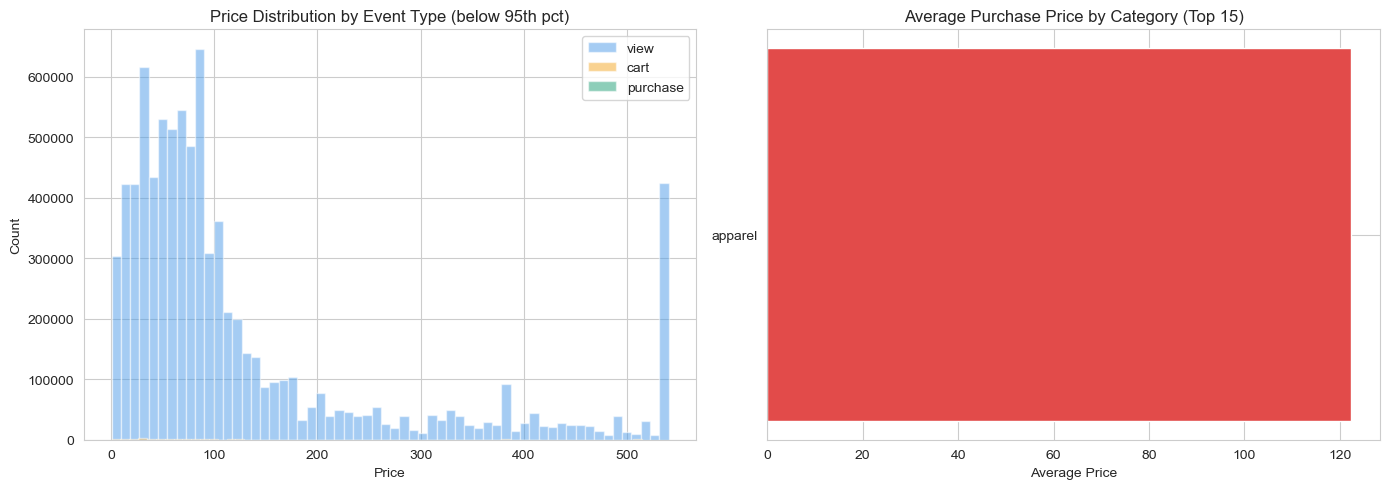

Strategy Insight:
  - If purchase mean > view mean -> users buy higher-priced items
  - Price tier useful as a user feature (avg spending level)


In [23]:
print('Price Distribution by Event Type')
for et in ['view','cart','purchase']:
    sub = df[df['event_type']==et]['price'].dropna()
    print(f"  {et:<10}: mean={sub.mean():.0f}  median={sub.median():.0f}  "
          f"min={sub.min():.0f}  max={sub.max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'view': '#4C9BE8', 'cart': '#F5A623', 'purchase': '#1D9E75'}
for et in ['view','cart','purchase']:
    sub = df[df['event_type']==et]['price'].dropna()
    axes[0].hist(sub.clip(upper=sub.quantile(0.95)), bins=60,
                 alpha=0.5, label=et, color=colors[et])
axes[0].set_title('Price Distribution by Event Type (below 95th pct)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')
axes[0].legend()

cat_price = (df[df['event_type']=='purchase']
             .groupby('category_top')['price'].mean()
             .sort_values(ascending=False).head(15))
axes[1].barh(cat_price.index[::-1], cat_price.values[::-1], color='#E24B4A')
axes[1].set_title('Average Purchase Price by Category (Top 15)')
axes[1].set_xlabel('Average Price')

plt.tight_layout()
plt.show()

print('Strategy Insight:')
print('  - If purchase mean > view mean -> users buy higher-priced items')
print('  - Price tier useful as a user feature (avg spending level)')

---
## 9. Repeat Purchase Analysis

In [24]:
purchase_df        = df[df['event_type'] == 'purchase'].copy()
user_item_purchase = purchase_df.groupby(['user_id','item_id']).size().reset_index(name='buy_count')
repeat_buys        = user_item_purchase[user_item_purchase['buy_count'] > 1]
single_buys        = user_item_purchase[user_item_purchase['buy_count'] == 1]
total_pairs        = len(user_item_purchase)

print('Repeat Purchase Analysis')
print(f"  Total (user, item) purchase pairs : {total_pairs:,}")
print(f"  Single purchase (1x)              : {len(single_buys):,} ({len(single_buys)/total_pairs*100:.1f}%)")
print(f"  Repeat purchase (2x+)             : {len(repeat_buys):,} ({len(repeat_buys)/total_pairs*100:.1f}%)")
print()
print('Repeat count distribution:')
print(user_item_purchase['buy_count'].value_counts().head(10).to_string())

Repeat Purchase Analysis
  Total (user, item) purchase pairs : 1,874
  Single purchase (1x)              : 1,742 (93.0%)
  Repeat purchase (2x+)             : 132 (7.0%)

Repeat count distribution:
buy_count
1     1742
2       96
3       19
4       12
5        2
8        1
9        1
10       1


In [25]:
user_item_purchase['buy_count'].value_counts().head(10)

buy_count
1     1742
2       96
3       19
4       12
5        2
8        1
9        1
10       1
Name: count, dtype: int64

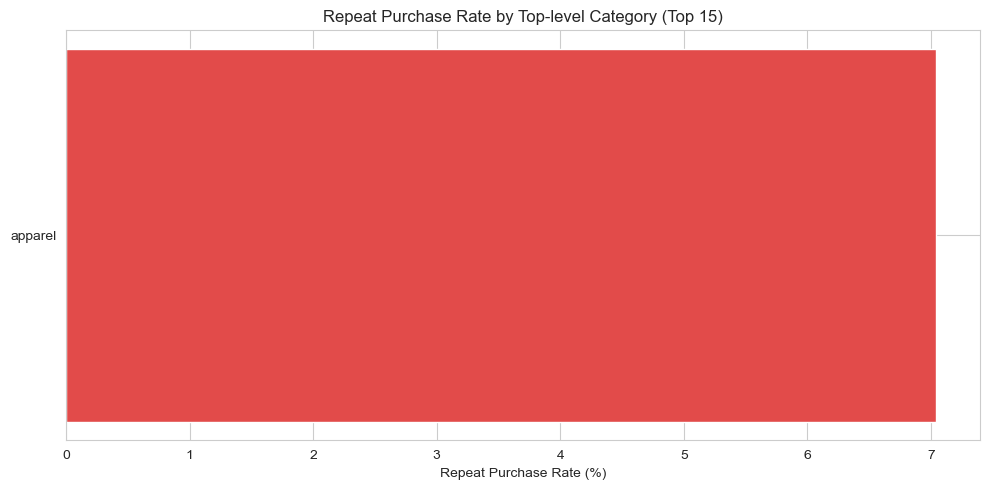

In [26]:
purchase_with_cat = purchase_df.merge(
    df[['item_id','category_top']].drop_duplicates('item_id'), on='item_id', how='left'
)
cat_repeat = (
    purchase_df
    .groupby(['user_id', 'item_id', 'category_top'])
    .size()
    .reset_index(name='cnt')
)

cat_repeat_rate = (
    cat_repeat
    .groupby('category_top')
    .apply(lambda x: (x['cnt'] > 1).mean() * 100)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,5))
plt.barh(cat_repeat_rate.index[::-1], cat_repeat_rate.values[::-1],
         color='#E24B4A')
plt.title('Repeat Purchase Rate by Top-level Category (Top 15)')
plt.xlabel('Repeat Purchase Rate (%)')
plt.tight_layout()
plt.show()

---
## 10. Train/Test Continuity Analysis

In [27]:
df['month'] = df['event_time'].dt.month

monthly_users = {}
for m in sorted(df['month'].unique()):
    monthly_users[m] = set(df[df['month']==m]['user_id'].unique())

months = sorted(monthly_users.keys())
print('Monthly User Stats')
print(f"{'Month':<8} {'Users':>10} {'New Users':>12} {'Return Rate':>12}")
print('-' * 48)
for i, m in enumerate(months):
    u = monthly_users[m]
    if i == 0:
        print(f"  {m:<6} {len(u):>10,}  {'(baseline month)':>24}")
    else:
        prev         = monthly_users[months[i-1]]
        new_users    = len(u - prev)
        return_rate  = len(u & prev) / len(prev) * 100
        print(f"  {m:<6} {len(u):>10,}  {new_users:>10,} new  {return_rate:>8.1f}% return")

Monthly User Stats
Month         Users    New Users  Return Rate
------------------------------------------------
  1         234,021          (baseline month)
  2         199,881     140,718 new      25.3% return
  11        100,944      85,059 new       7.9% return
  12        298,335     266,783 new      31.3% return


In [28]:
feb_users  = set(df[df['month']==2]['user_id'].unique())
feb_buyers = set(df[(df['month']==2) & (df['event_type']=='purchase')]['user_id'].unique())

print('February Analysis (month directly before test period)')
print(f"  Active users in Feb  : {len(feb_users):,}")
print(f"  Buyers in Feb        : {len(feb_buyers):,} ({len(feb_buyers)/len(feb_users)*100:.1f}% of active)")

feb_last_week        = df[(df['event_time'] >= '2020-02-22') & (df['event_type']=='purchase')]
feb_last_week_buyers = set(feb_last_week['user_id'].unique())
print(f"  Buyers in last week of Feb (2/22~2/29): {len(feb_last_week_buyers):,}")
print(f"  -> Most likely to purchase again in March")

feb_cart_users   = set(df[(df['month']==2) & (df['event_type']=='cart')]['user_id'].unique())
feb_cart_not_buy = feb_cart_users - feb_buyers
print(f"  Cart-only in Feb (no purchase): {len(feb_cart_not_buy):,}")
print(f"  -> Their cart items are strong March purchase candidates")

print('\nStrategy Insight:')
print('  - Low Feb buyer rate -> time decay is important')
print('  - Cart-but-no-purchase users -> rule-based cart item re-ranking in March')
print('  - Low monthly return rate -> many inactive users, cold-start handling is critical')

February Analysis (month directly before test period)
  Active users in Feb  : 199,881
  Buyers in Feb        : 1,237 (0.6% of active)
  Buyers in last week of Feb (2/22~2/29): 1,105
  -> Most likely to purchase again in March
  Cart-only in Feb (no purchase): 4,443
  -> Their cart items are strong March purchase candidates

Strategy Insight:
  - Low Feb buyer rate -> time decay is important
  - Cart-but-no-purchase users -> rule-based cart item re-ranking in March
  - Low monthly return rate -> many inactive users, cold-start handling is critical


In [29]:
val_purchases = df[(df['event_time'] >= '2020-02-01') &
                   (df['event_time'] <= '2020-02-07') &
                   (df['event_type'] == 'purchase')]

print('Local Validation Set (Feb 1-7 purchases)')
print(f"  Purchase events : {len(val_purchases):,}")
print(f"  Unique users    : {val_purchases['user_id'].nunique():,}")
print(f"  Unique items    : {val_purchases['item_id'].nunique():,}")
print("""
Setup:
  train_local = df[df['event_time'] < '2020-02-01']
  test_local  = df[(df['event_time'] >= '2020-02-01') &
                   (df['event_time'] <= '2020-02-07') &
                   (df['event_type'] == 'purchase')]
  # Train on train_local, evaluate NDCG@10 on test_local
  # -> Tune hyperparameters without using submission quota
""")

Local Validation Set (Feb 1-7 purchases)
  Purchase events : 94
  Unique users    : 88
  Unique items    : 72

Setup:
  train_local = df[df['event_time'] < '2020-02-01']
  test_local  = df[(df['event_time'] >= '2020-02-01') &
                   (df['event_time'] <= '2020-02-07') &
                   (df['event_type'] == 'purchase')]
  # Train on train_local, evaluate NDCG@10 on test_local
  # -> Tune hyperparameters without using submission quota



---
## 11. Interaction Matrix Sparsity

In [30]:
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()

n_interactions_all = df.groupby(['user_id','item_id']).ngroups
sparsity_all       = 1 - n_interactions_all / (n_users * n_items)

n_interactions_buy = purchase_df.groupby(['user_id','item_id']).ngroups
sparsity_buy       = 1 - n_interactions_buy / (n_users * n_items)

print('Interaction Matrix Sparsity')
print(f"  Matrix size: {n_users:,} x {n_items:,} = {n_users*n_items:,}")
print()
print(f"  [All events]")
print(f"    Observed pairs: {n_interactions_all:,}")
print(f"    Sparsity       : {sparsity_all*100:.4f}%")
print(f"    Density        : {(1-sparsity_all)*100:.4f}%")
print()
print(f"  [Purchase only]")
print(f"    Observed pairs: {n_interactions_buy:,}")
print(f"    Sparsity       : {sparsity_buy*100:.4f}%")
print(f"    Density        : {(1-sparsity_buy)*100:.4f}%")

print('\nStrategy Insight:')
print('  - Sparsity >99.99% -> ALS with too many factors risks overfitting')
print('  - EASE is especially effective on extremely sparse data')
print('  - SASRec as a sequence model is less affected by sparsity')

Interaction Matrix Sparsity
  Matrix size: 638,257 x 29,502 = 18,829,858,014

  [All events]
    Observed pairs: 5,943,059
    Sparsity       : 99.9684%
    Density        : 0.0316%

  [Purchase only]
    Observed pairs: 1,874
    Sparsity       : 100.0000%
    Density        : 0.0000%

Strategy Insight:
  - Sparsity >99.99% -> ALS with too many factors risks overfitting
  - EASE is especially effective on extremely sparse data
  - SASRec as a sequence model is less affected by sparsity


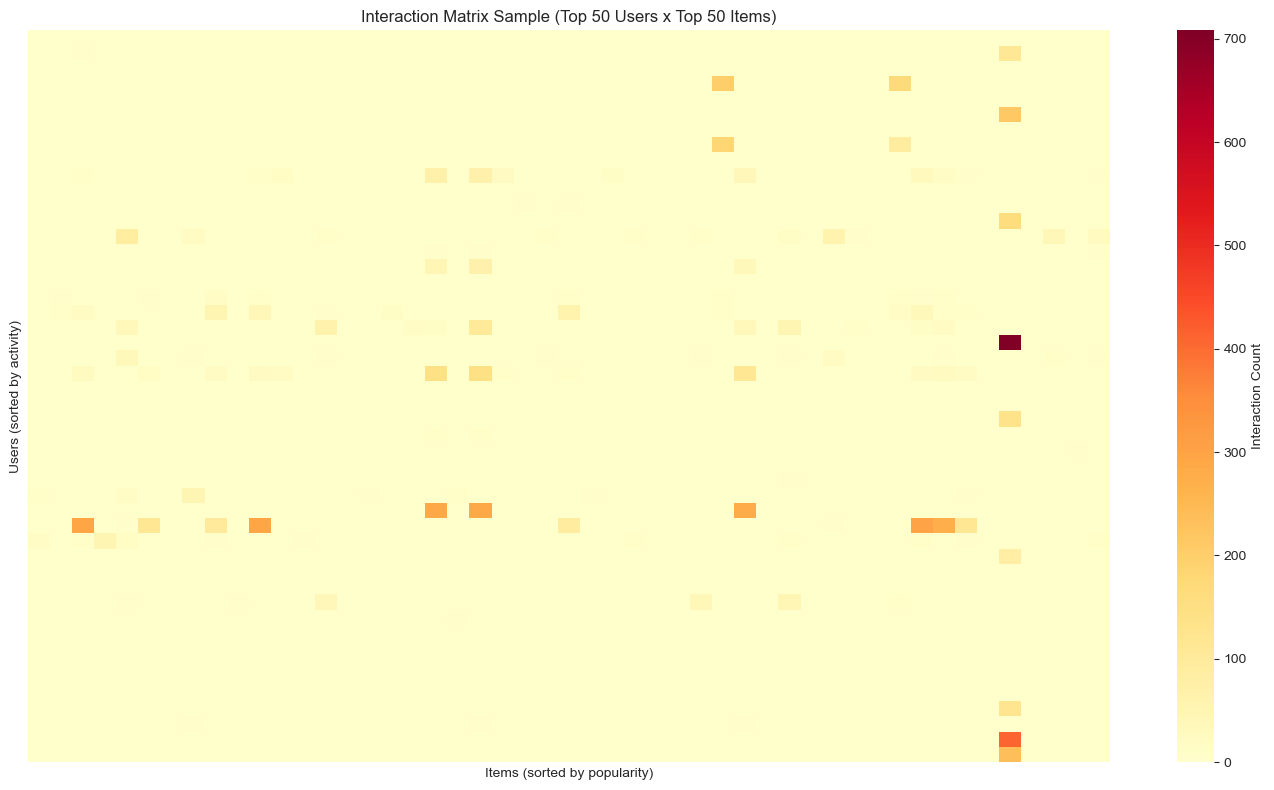

Empty cell ratio in sample: 88.1% (even among top users/items)


In [31]:
top50_users = df['user_id'].value_counts().head(50).index
top50_items = df['item_id'].value_counts().head(50).index

sample_matrix = df[
    df['user_id'].isin(top50_users) & df['item_id'].isin(top50_items)
].groupby(['user_id','item_id'])['event_type'].count().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(sample_matrix, cmap='YlOrRd',
            cbar_kws={'label': 'Interaction Count'},
            xticklabels=False, yticklabels=False)
plt.title('Interaction Matrix Sample (Top 50 Users x Top 50 Items)')
plt.xlabel('Items (sorted by popularity)')
plt.ylabel('Users (sorted by activity)')
plt.tight_layout()
plt.show()

zero_ratio = (sample_matrix == 0).sum().sum() / sample_matrix.size * 100
print(f"Empty cell ratio in sample: {zero_ratio:.1f}% (even among top users/items)")

---
## 12. Strategy Summary

In [32]:
print("""
=================================================================
  EDA-Based Modeling Strategy Summary
=================================================================

  [1] ALS Weight Design
      - Event weights from view:cart:purchase ratio in EDA
      - Time decay: exp(-lambda * days_ago), tune lambda
      - filter_already_liked_items: based on repeat-buy rate

  [2] Cold Start Handling
      - No-purchase users -> sub-category popular items fallback
      - SASRec inter_num threshold: based on user dist
      - Last-week-Feb buyers -> highest-priority target users

  [3] Feature Engineering (for 2-stage re-ranking)
      - User features : preferred sub-category, avg price, freq
      - Item features : conversion rate, category, repeat rate
      - Cross features: user-category match, user-brand affinity

  [4] Additional Models (priority order)
      1st: EASE  (strong on sparse matrices, easy to implement)
      2nd: GRU4Rec (different sequential model, good for ensemble)
      3rd: LightFM (uses sub-category as side information)

  [5] Local Validation
      - train: up to 2020-01-31 / test: 2020-02-01 ~ 02-07
      - Measure NDCG@10 locally before each submission

  [6] Cart-based Re-ranking Rule
      - Feb cart-not-purchased items = strong March buy candidates
      - Boost these items to top positions after model scoring

=================================================================""")


  EDA-Based Modeling Strategy Summary

  [1] ALS Weight Design
      - Event weights from view:cart:purchase ratio in EDA
      - Time decay: exp(-lambda * days_ago), tune lambda
      - filter_already_liked_items: based on repeat-buy rate

  [2] Cold Start Handling
      - No-purchase users -> sub-category popular items fallback
      - SASRec inter_num threshold: based on user dist
      - Last-week-Feb buyers -> highest-priority target users

  [3] Feature Engineering (for 2-stage re-ranking)
      - User features : preferred sub-category, avg price, freq
      - Item features : conversion rate, category, repeat rate
      - Cross features: user-category match, user-brand affinity

  [4] Additional Models (priority order)
      1st: EASE  (strong on sparse matrices, easy to implement)
      2nd: GRU4Rec (different sequential model, good for ensemble)
      3rd: LightFM (uses sub-category as side information)

  [5] Local Validation
      - train: up to 2020-01-31 / test: 2020-02-01

In [33]:
summary = {
    'Total events':               f"{len(df):,}",
    'Unique users':               f"{n_users:,}",
    'Unique items':               f"{n_items:,}",
    'view ratio':                 f"{event_pct.get('view', 0):.1f}%",
    'cart ratio':                 f"{event_pct.get('cart', 0):.1f}%",
    'purchase ratio':             f"{event_pct.get('purchase', 0):.1f}%",
    'view->purchase rate':        f"{purchase_n/view_n*100:.2f}%",
    'Repeat purchase rate':       f"{len(repeat_buys)/total_pairs*100:.1f}%",
    'Interaction matrix density': f"{(1-sparsity_all)*100:.4f}%",
    'Users with no purchase':     f"{users_no_purchase:,} ({users_no_purchase/total_users*100:.1f}%)",
    'Feb cart-not-bought users':  f"{len(feb_cart_not_buy):,}",
    'Feb last-week buyers':       f"{len(feb_last_week_buyers):,}",
}

print('EDA Key Metrics Summary')
print('=' * 55)
for k, v in summary.items():
    print(f"  {k:<30}: {v}")

EDA Key Metrics Summary
  Total events                  : 8,350,311
  Unique users                  : 638,257
  Unique items                  : 29,502
  view ratio                    : 99.8%
  cart ratio                    : 0.2%
  purchase ratio                : 0.0%
  view->purchase rate           : 0.02%
  Repeat purchase rate          : 7.0%
  Interaction matrix density    : 0.0316%
  Users with no purchase        : 636,576 (99.7%)
  Feb cart-not-bought users     : 4,443
  Feb last-week buyers          : 1,105
